NOTE: This is the short version of the lecture and is meant to be viewed as an .ipynb ( Python Jupyter Notebook esp. in Google Colab: https://colab.research.google.com/drive/1VrXGUciI3kuCDKtfKvT87zxSm9apiA_Q?usp=sharing )

Please, contact author Robin Yancey for .ipynb or use above link.

# k-Nearest Neighbors (kNN): Mathematical Theory and Python Implementation

This lecture notebook focuses on the mathematical foundations of the kNN algorithm, including distance metrics, geometric intuition, decision boundaries, bias-variance tradeoffs, and practical implementation in Python with Sklearn.

# Introduction


k-Nearest Neighbors (kNN) is a non-parametric, instance-based supervised learning algorithm.
Unlike many machine learning algorithms, kNN does not explicitly learn a model.
Instead, it stores the training data and makes predictions based on nearby examples.

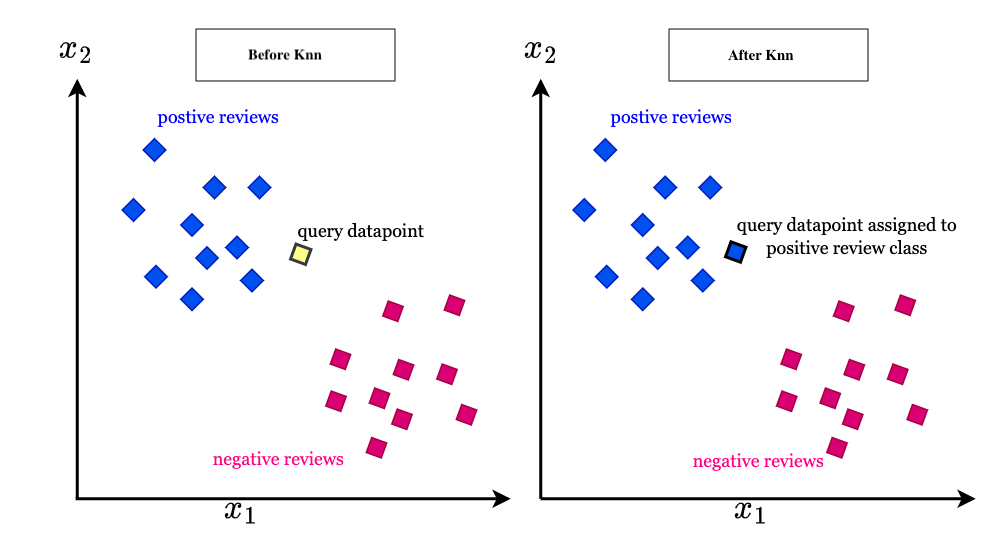

# Geometric Interpretation


Each observation is represented as a point in an n-dimensional feature space.
Classification is performed by examining the k closest points to a query point. Smaller distances indicate greater similarity.
The majority class among neighbors becomes the prediction for classification.

### Question: What do you think we do differently with regression?




##Answer:



We average the y-values/outcomes of the k nearest neighbors.

## Euclidean Distance


The most common distance metric is Euclidean distance:

d(x,y)=√Σ(xi−yi)²




## Manhattan Distance


Manhattan distance is also often used:

d(x,y)=Σ|xi−yi|



## Bias-Variance Tradeoff


Small k:
- Low bias
- High variance
- Sensitive to noise

Large k:
- Higher bias
- Lower variance
- Smoother decision boundaries


## Curse of Dimensionality


As dimensionality increases, distances become less meaningful.
Feature scaling and dimensionality reduction often improve performance.


## Classification Rule


For a query point x:

1. Compute distances to all training examples.
2. Sort distances.
3. Select k nearest neighbors.
4. Perform majority vote.
5. Assign the most common class.


# Manual kNN Algorithm Implementation

In [1]:
import numpy as np

def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

x = np.array([1,2,3])
y = np.array([4,5,6])
print('Distance:', euclidean_distance(x,y))

Distance: 5.196152422706632


In [2]:
from collections import Counter
import numpy as np

def knn_predict(X_train, y_train, query, k=3):
    distances = []
    for i in range(len(X_train)):
        d = np.sqrt(np.sum((X_train[i]-query)**2))
        distances.append((d, y_train[i]))

    distances.sort(key=lambda x: x[0])
    neighbors = [label for _, label in distances[:k]]
    return Counter(neighbors).most_common(1)[0][0]

# Scikit-Learn Implementation

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# create an instance of the model with n neighbors
knn = KNeighborsClassifier(n_neighbors=10)
# apply the model (and .fit usually does the training)
knn.fit(X_train, y_train)
# test and compute score
print('Accuracy:', knn.score(X_test, y_test))

Accuracy: 1.0


# How does KNN handle categorical features in the dataset?
 KNN can handle categorical features through appropriate encoding techniques. One common approach is to use **one-hot encoding**, where each category is represented as a binary feature. Another method is to convert categorical features into numerical values using **label encoding**. However, it’s essential to choose an encoding method that preserves the inherent characteristics of the categorical data and ensures meaningful distance calculations between data points.

## Advantages of KNN

The effectiveness of KNN increase with large training data and so it supports sufficient data representation.

KNN can be used for both classification and regression.

KNN is non parametric and hence no assumptions associated with the underlying data. Hence, it can be used for nonlinear data as well.



## Disadvantages of KNN algorithm

Measuring the distance between all data points in training samples is a computationally expensive task.

If the training data is excessively randomized, then assigning a class label based on distance measure is messy.

KNN is not a suitable option for query points at farther distance from the training data.